In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
train_df = pd.read_excel('LR_train_data.xlsx')
test_df  = pd.read_excel('LR_test_data.xlsx')

In [17]:
X_train_full = train_df[['x1', 'x2']].values
y_train_full = train_df['y'].values
X_test = test_df[['x1', 'x2']].values
y_test= test_df['y'].values

In [18]:
np.random.seed(42)

rd = np.random.permutation(len(X_train_full))
split = int(0.8 * len(X_train_full))
train_rd, val_rd = rd[:split], rd[split:]

X_train, y_train = X_train_full[train_rd], y_train_full[train_rd]
X_val,y_val = X_train_full[val_rd],y_train_full[val_rd]

print(f"Train samples     : {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples      : {len(X_test)}")

Train samples     : 80
Validation samples: 20
Test samples      : 50


In [19]:
def mse_fn(y, yhat):
    return np.mean((y - yhat) ** 2)

In [20]:
def poly_map(X, deg):
    x1 = X[:, 0]
    x2 = X[:, 1]

    cols = [np.ones(X.shape[0])]   # bias

    for d in range(1, deg + 1):
        for i in range(d + 1):
            cols.append((x1 ** (d - i)) * (x2 ** i))

    return np.column_stack(cols)

In [21]:
def ridge_cf(X, y, lam):
    p = X.shape[1]
    I = np.eye(p)
    I[0, 0] = 0
    return np.linalg.inv(X.T @ X + lam * I) @ X.T @ y

In [23]:
deg_list = list(range(1, 10))
tr_err = []
va_err = []
te_err = []

print(f"{'Deg':<6} {'Prm':<9} {'Train':<13} {'Val':<13} ")

for d in deg_list:

    Xt = poly_map(X_train, d)
    Xv = poly_map(X_val,   d)
    Xs = poly_map(X_test,  d)


    XtT = Xt.T
    w = np.linalg.inv(XtT @ Xt) @ (XtT @ y_train)

    ytr = Xt @ w
    yva = Xv @ w
    yte = Xs @ w

    tr = mse_fn(y_train, ytr)
    va = mse_fn(y_val,   yva)
    te = mse_fn(y_test,  yte)

    tr_err.append(tr)
    va_err.append(va)
    te_err.append(te)



    print(f"{d:<6} {Xt.shape[1]:<9} {tr:<13.4f} {va:<13.4f} ")



Deg    Prm       Train         Val           
1      3         0.3711        0.5409        
2      6         0.3608        0.5762        
3      10        0.3507        0.6219        
4      15        0.3252        4.0769        
5      21        0.2997        0.6840        
6      28        0.2680        0.7772        
7      36        0.5318        390.4427      
8      45        444.8753      24144.8298    
9      55        299.4117      61235.1984    


In [24]:
BEST_DEG = 7

In [39]:

lam_list = np.logspace(-4, 4, 40)

# Build polynomial for train/val

Xtr = poly_map(X_train, BEST_DEG)
Xv  = poly_map(X_val,   BEST_DEG)


# OLS on split (reference)

w_ols_split = np.linalg.inv(Xtr.T @ Xtr) @ Xtr.T @ y_train
val_ols = mse_fn(y_val, Xv @ w_ols_split)

# Ridge: Select Best λ

val_errs = []
test_errs = []

Xte_split = poly_map(X_test, BEST_DEG)

for lam in lam_list:
    w_tmp = ridge_cf(Xtr, y_train, lam)
    val_errs.append(mse_fn(y_val, Xv @ w_tmp))
    test_errs.append(mse_fn(y_test, Xte_split @ w_tmp))


best_lam = lam_list[np.argmin(val_errs)]

print("Selected lambda (validation):", best_lam)


# Retrain on FULL Training Data

Xfull = poly_map(X_train_full, BEST_DEG)
Xte   = poly_map(X_test, BEST_DEG)

# OLS Final

w_ols_final = np.linalg.inv(Xfull.T @ Xfull) @ Xfull.T @ y_train_full
train_ols = mse_fn(y_train_full, Xfull @ w_ols_final)
test_ols  = mse_fn(y_test, Xte @ w_ols_final)

# Ridge Final

w_ridge_final = ridge_cf(Xfull, y_train_full, best_lam)
train_ridge = mse_fn(y_train_full, Xfull @ w_ridge_final)
test_ridge  = mse_fn(y_test, Xte @ w_ridge_final)

Xfull = poly_map(X_train_full, BEST_DEG)
Xte   = poly_map(X_test, BEST_DEG)

train_pred = Xfull @ w_ridge_final
test_pred  = Xte @ w_ridge_final


# Final Comparison

print("FINAL COMPARISON ")
print("OLS   Train MSE :", train_ols)
print("OLS   Test  MSE :", test_ols)

print("\nRidge Train MSE :", train_ridge)
print("Ridge Test  MSE :", test_ridge)

Selected lambda (validation): 1.2663801734674023
FINAL COMPARISON 
OLS   Train MSE : 11.029081840897206
OLS   Test  MSE : 14238176058601.953

Ridge Train MSE : 0.3899386716046403
Ridge Test  MSE : 758889939237.6562


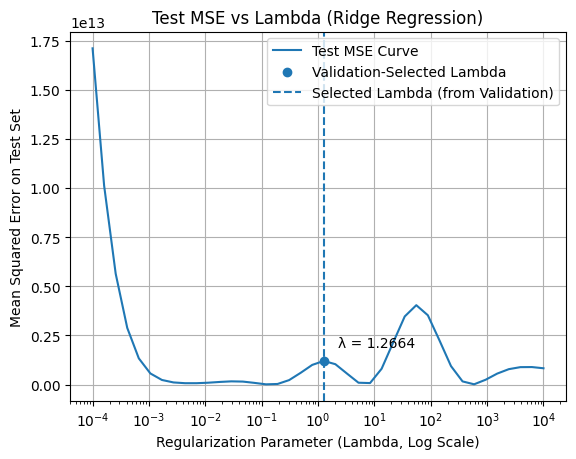

In [40]:
plt.figure()


plt.semilogx(lam_list, test_errs, label="Test MSE Curve")


best_idx = np.argmin(val_errs)
best_lam = lam_list[best_idx]
best_test_mse = test_errs[best_idx]


plt.scatter(best_lam, best_test_mse, label="Validation-Selected Lambda")

plt.axvline(best_lam, linestyle='--', label="Selected Lambda (from Validation)")


plt.annotate(
    f"λ = {best_lam:.4f}",
    (best_lam, best_test_mse),
    textcoords="offset points",
    xytext=(10,10)
)

plt.xlabel("Regularization Parameter (Lambda, Log Scale)")
plt.ylabel("Mean Squared Error on Test Set")
plt.title("Test MSE vs Lambda (Ridge Regression)")

plt.legend()
plt.grid(True)
plt.show()

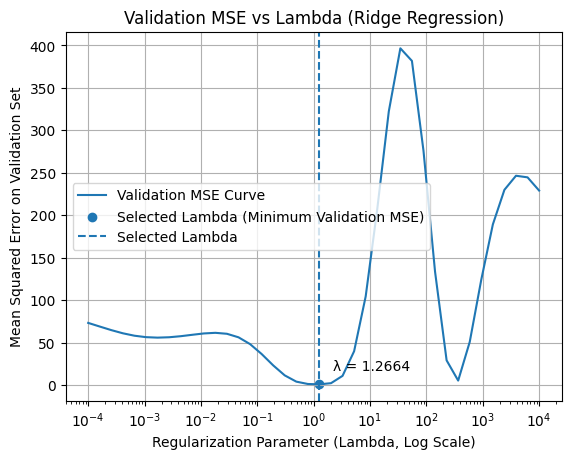

In [41]:

import numpy as np

plt.figure()

plt.semilogx(lam_list, val_errs, label="Validation MSE Curve")

best_idx = np.argmin(val_errs)
best_lam = lam_list[best_idx]
best_val_mse = val_errs[best_idx]

plt.scatter(best_lam, best_val_mse, label="Selected Lambda (Minimum Validation MSE)")
plt.axvline(best_lam, linestyle='--', label="Selected Lambda")

plt.annotate(
    f"λ = {best_lam:.4f}",
    (best_lam, best_val_mse),
    textcoords="offset points",
    xytext=(10,10)
)

plt.xlabel("Regularization Parameter (Lambda, Log Scale)")
plt.ylabel("Mean Squared Error on Validation Set")
plt.title("Validation MSE vs Lambda (Ridge Regression)")

plt.legend()
plt.grid(True)
plt.show()

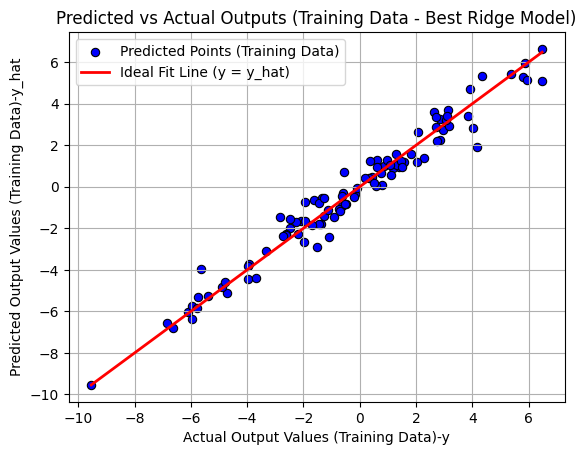

In [50]:
plt.figure()

plt.scatter(
    y_train_full,
    train_pred,
    color='blue',
    edgecolors='black',
    linewidth=0.8,
    label="Predicted Points (Training Data)"
)

plt.plot(
    [min(y_train_full), max(y_train_full)],
    [min(y_train_full), max(y_train_full)],
    color='red',
    linewidth=2,
    label="Ideal Fit Line (y = y_hat)"
)

plt.xlabel("Actual Output Values (Training Data)-y")
plt.ylabel("Predicted Output Values (Training Data)-y_hat")
plt.title("Predicted vs Actual Outputs (Training Data - Best Ridge Model)")

plt.legend()
plt.grid(True)
plt.show()

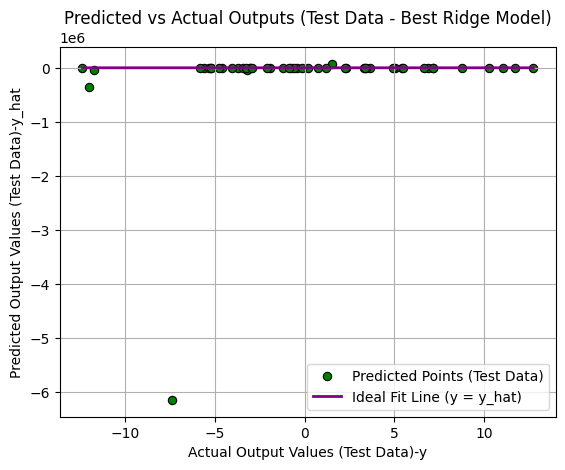

In [51]:
plt.figure()

plt.scatter(
    y_test,
    test_pred,
    color='green',
    edgecolors='black',
    linewidth=0.8,
    label="Predicted Points (Test Data)"
)

plt.plot(
    [min(y_test), max(y_test)],
    [min(y_test), max(y_test)],
    color='purple',
    linewidth=2,
    label="Ideal Fit Line (y = y_hat)"
)

plt.xlabel("Actual Output Values (Test Data)-y")
plt.ylabel("Predicted Output Values (Test Data)-y_hat")
plt.title("Predicted vs Actual Outputs (Test Data - Best Ridge Model)")

plt.legend()
plt.grid(True)
plt.show()